In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from models.hierarchical_grating_model import HierarchicalGratingModel
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity

seed = 42
rng = np.random.default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# define all constants here
G_dim = 2
G_prob = 1/G_dim
x_sigma = .1
I_sigma = 10
offset = 0
G_visual_nrows = 2
G_visual_ncols = 1
x_visual_nrows = 2
x_visual_ncols = 9
n_tune = 300
n_draws = 300
n_chains = 4
n_cores = 4

In [3]:
exc_fname = Path("/src/project/data/experiment/exc_images_preprocessed.npy")
exc_images = np.load(exc_fname)
print(exc_images.shape)

(960, 36, 36)


In [4]:
exc_images_mean = exc_images.mean(axis=0)
exc_images = exc_images - exc_images_mean
vmin = np.min(exc_images)
vmax = np.max(exc_images)

In [5]:
# fig, axs = plt.subplots(10, 10, dpi=300)
# vmin = np.min(exc_images)
# vmax = np.max(exc_images)
# for idx, ax in enumerate(axs.flatten()):
#     ax.imshow(exc_images[idx], cmap="gray", vmin=vmin, vmax=vmax)
#     ax.axis("off")

In [6]:
# I_sigmas = np.arange(start=1, stop=100, step=10)
# print(I_sigmas)

In [7]:
# model_images = exc_images[-G_dim:]
model_images = np.array([exc_images[0], exc_images[1]])
model = HierarchicalGratingModel(
    gratings=model_images,
    G_prob=G_prob,
    X_sigma=x_sigma,
    I_sigma=I_sigma,
    gratings_offset=offset
)

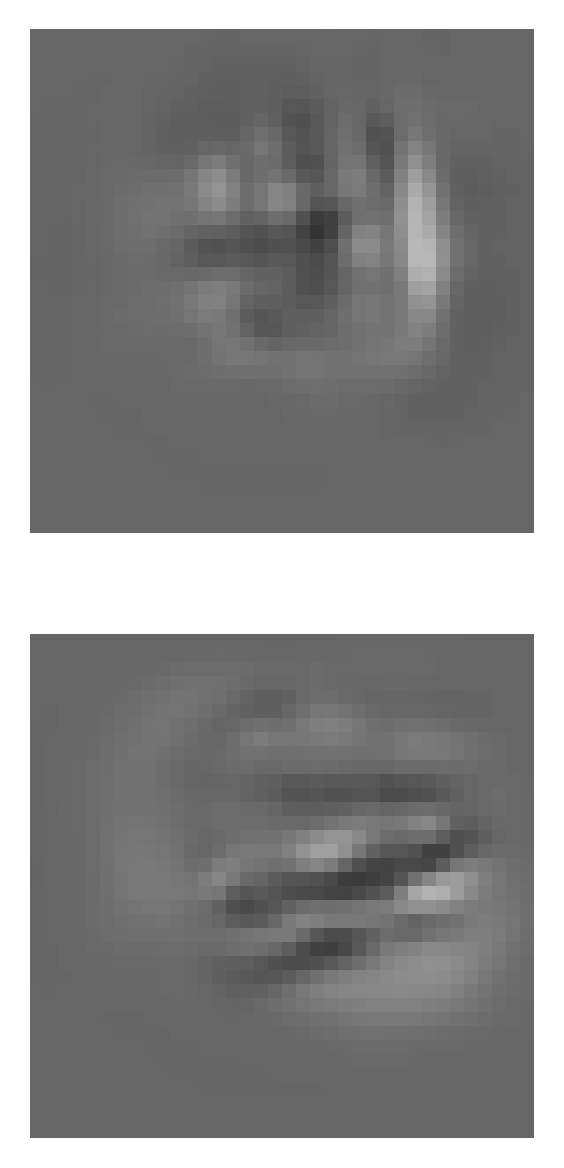

In [8]:
fig, axs = plt.subplots(G_visual_nrows, G_visual_ncols, dpi=300)
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(model.gratings[idx], cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

(0.0, 2.0, 2.0, 0.0)

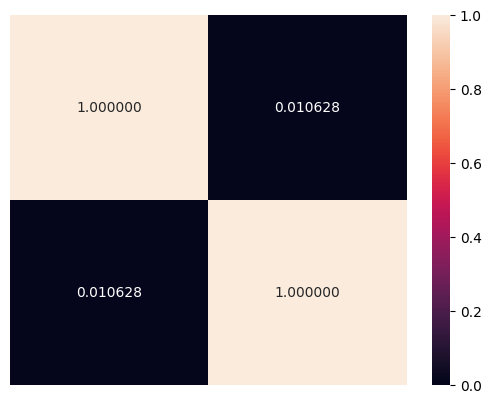

In [9]:
fig, ax = plt.subplots()
sns.heatmap(cosine_similarity(model.gratings[-G_dim:].reshape(model.gratings.shape[0], -1)), annot=True, fmt="f", ax=ax, vmin=0, vmax=1)
# im = ax.imshow(cosine_similarity(model.gratings[-G_dim:].reshape(model.gratings.shape[0], -1)), cmap="seismic", vmin=-1, vmax=1)
# plt.colorbar(im, ax=ax)
plt.axis('off')

(-0.5, 17.5, 1.5, -0.5)

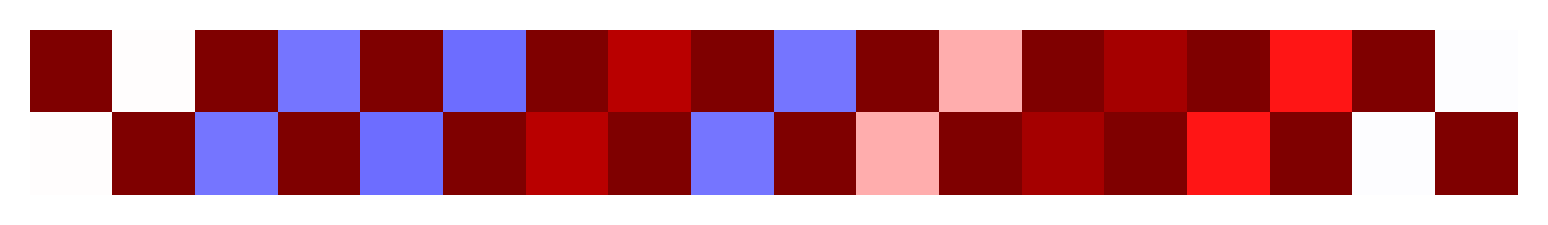

In [10]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
ax.axis('off')

Text(0.5, 1.0, 'G-X mapping histogram')

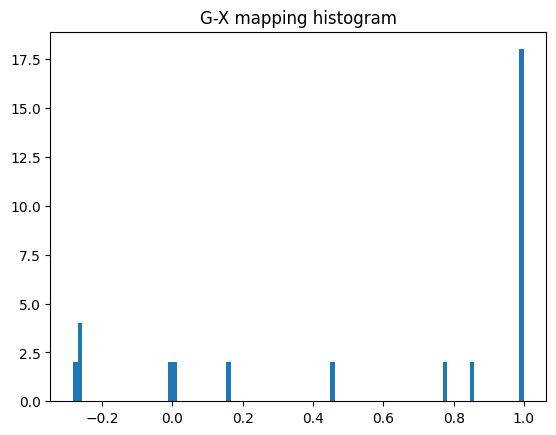

In [11]:
plt.hist(model.G_X_mapping.ravel(), bins=100)
# add title 
plt.title("G-X mapping histogram")

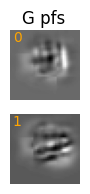

In [12]:
model.visualize_learned_G(nrows=G_visual_nrows, ncols=G_visual_ncols)

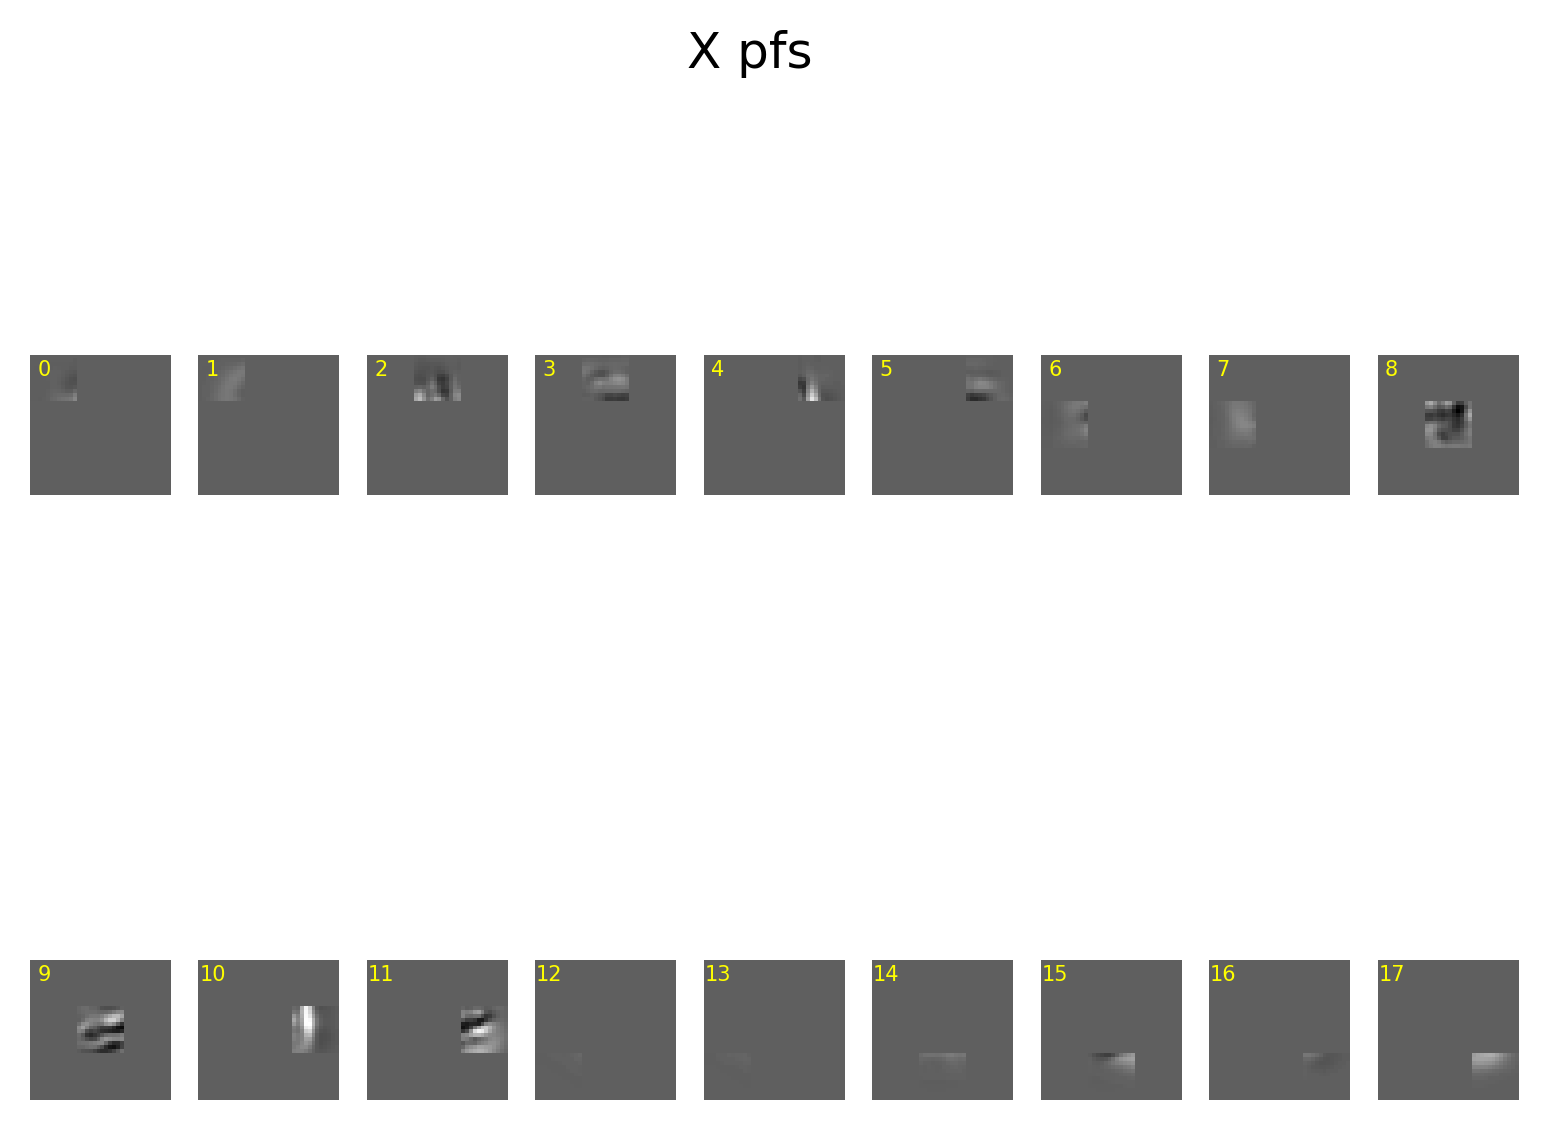

In [13]:
model.visualize_learned_X(nrows=x_visual_nrows, ncols=x_visual_ncols)

(-0.5, 35.5, 35.5, -0.5)

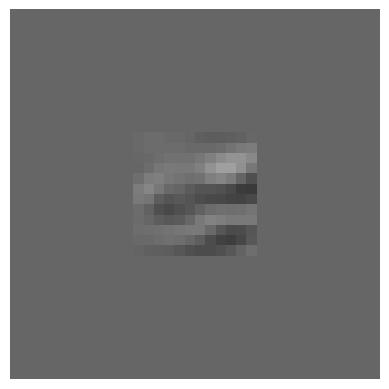

In [14]:
empty_image = np.zeros((36, 36))
empty_image[12:24, 12:24] = model.grating_crops[4][1].reshape(12, 12).copy()
MEI_center = model.grating_crops[4][1].reshape(12, 12).copy()
MEI = empty_image
plt.imshow(MEI, cmap="gray", vmin=vmin, vmax=vmax)
plt.axis("off")

(-0.5, 35.5, 35.5, -0.5)

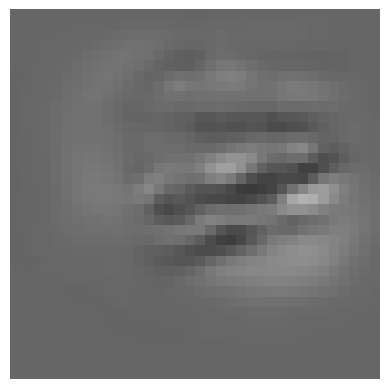

In [15]:
completing = model.gratings[1].copy()
plt.imshow(completing, cmap="gray", vmin=vmin, vmax=vmax)
plt.axis("off")

(-0.5, 35.5, 35.5, -0.5)

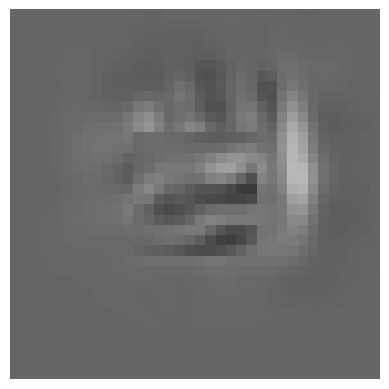

In [16]:
disrupting = model.gratings[0].copy()
disrupting[12:24, 12:24] = MEI_center
plt.imshow(disrupting, cmap="gray", vmin=vmin, vmax=vmax)
plt.axis("off")

In [17]:
np.min(model_images), np.max(model_images)

(-33.16744791666666, 56.033593749999994)

In [18]:
images = [MEI, completing, disrupting]
all_samples = []
for image in images:
    post_samples = model.sample_posterior(
        image=image,
        n_samples=n_draws,
        random_seed=42,
        tune=n_tune,
        chains=n_chains,
        cores=n_draws
    )

    all_samples.append(post_samples)

Only 300 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 300 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 25 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 300 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 26 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 300 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 26 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


In [19]:
n_neurons = G_dim * 9
all_x_samples_reshaped = []
for samples in all_samples:
    samples = samples['posterior']['X'].data.reshape(n_chains*n_draws, n_neurons)
    all_x_samples_reshaped.append(samples)

In [20]:
x_samples_chained = []
for samples in all_samples:
    samples = samples['posterior']['X'].data
    x_samples_chained.append(samples)

In [21]:
x_samples_chained[0].shape

(4, 300, 18)

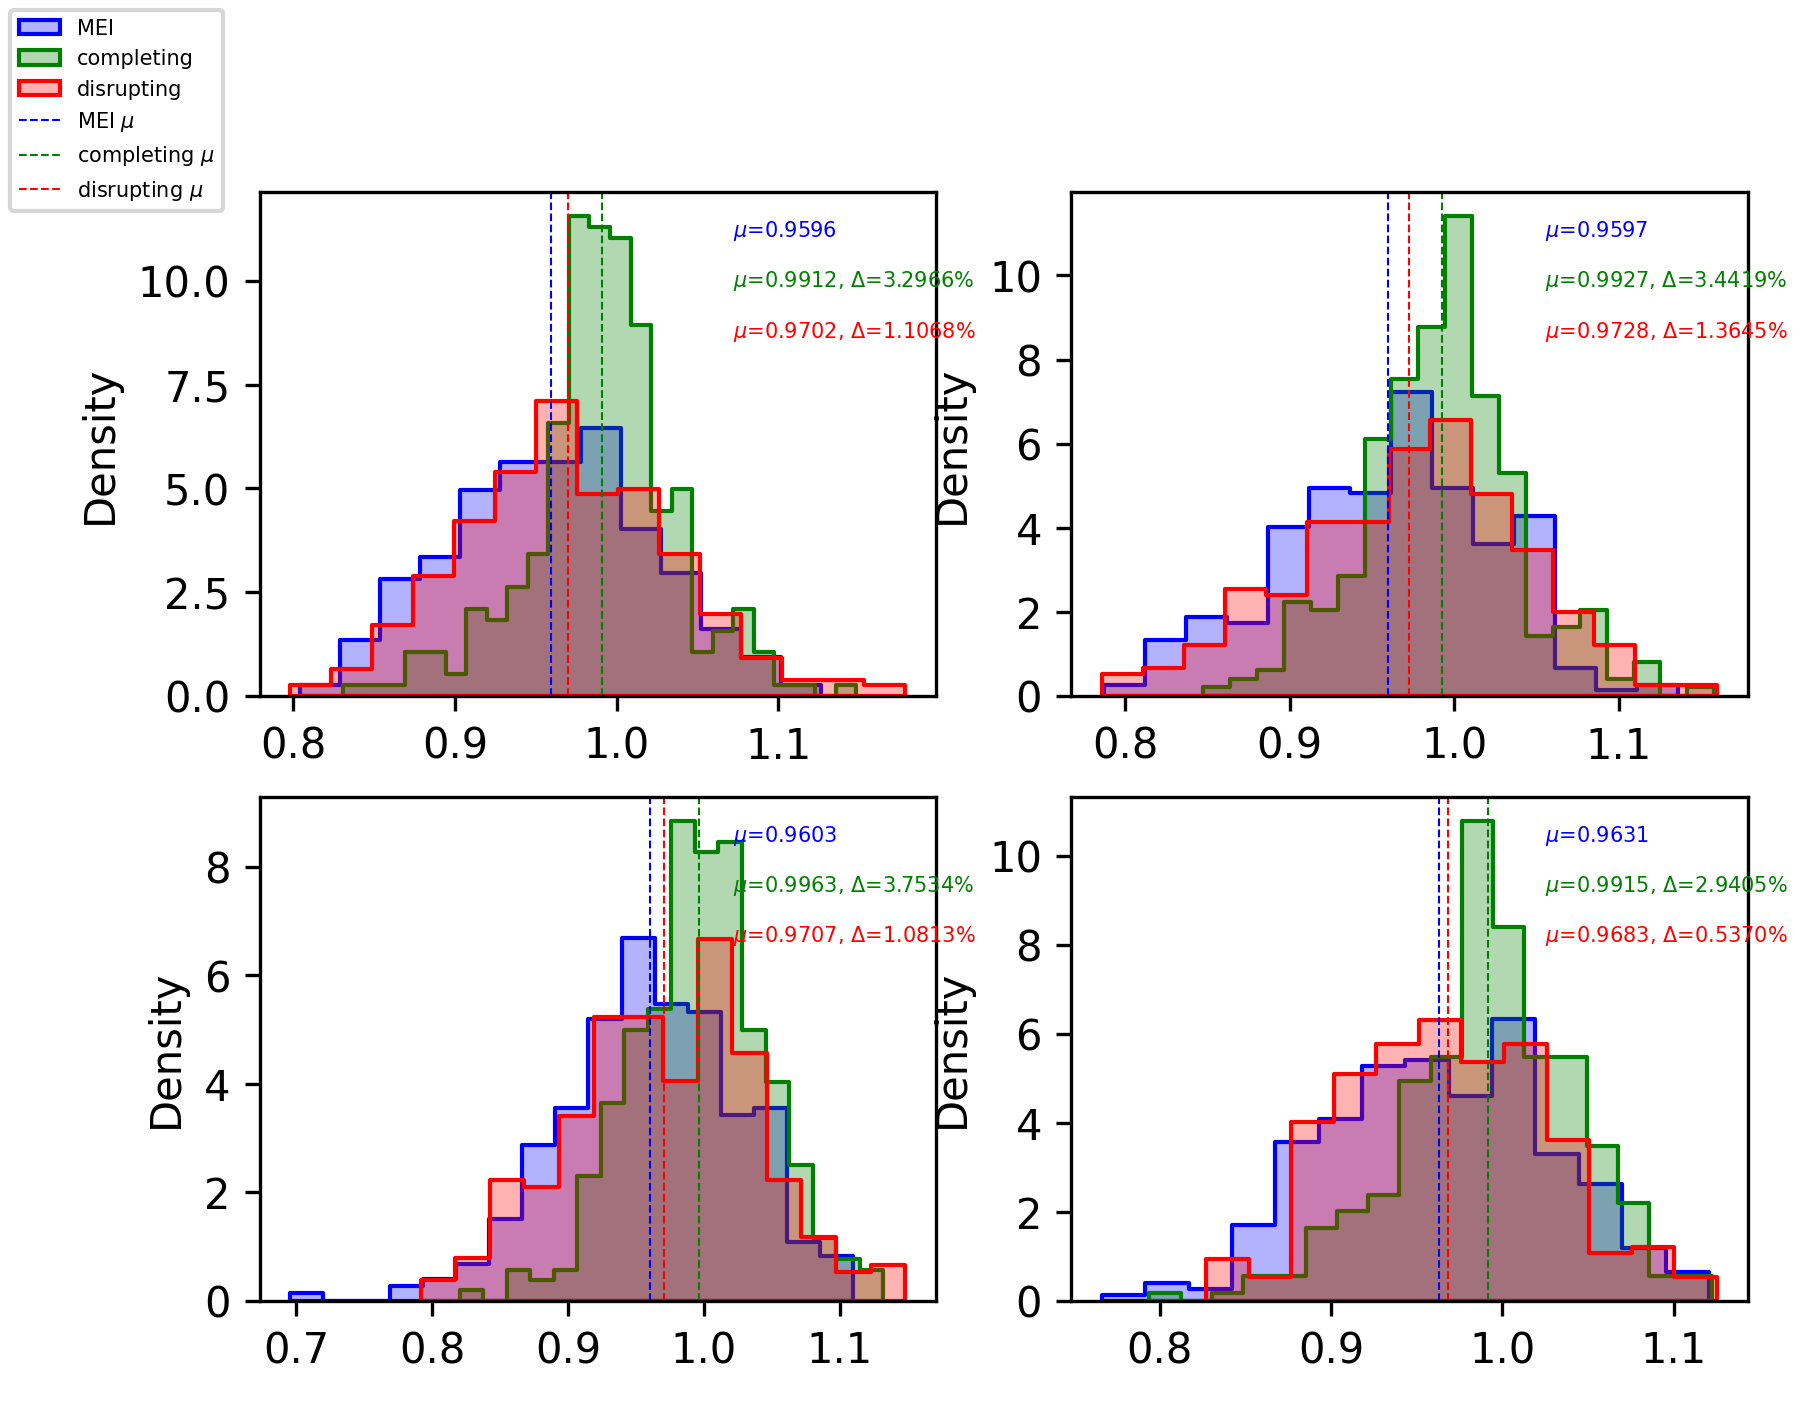

In [22]:
fig, axs = plt.subplots(nrows=2, ncols=2, dpi=300)
neuron_id = 9
for idx, ax in enumerate(axs.flatten()):
    mei_samples = x_samples_chained[0][idx][:, neuron_id]
    completing_samples = x_samples_chained[1][idx][:, neuron_id]
    disrupting_samples = x_samples_chained[2][idx][:, neuron_id]
    sns.histplot(
        mei_samples,
        ax=ax,
        stat="density",
        color="blue",
        element="step",
        alpha=0.3,
        label="MEI"
    )
    sns.histplot(
        completing_samples,
        ax=ax,
        stat="density",
        color="green",
        element="step",
        alpha=0.3,
        label="completing"
    )
    sns.histplot(
        disrupting_samples,
        ax=ax,
        stat="density",
        color="red",
        element="step",
        alpha=0.3,
        label="disrupting"
    )

    MEI_mean = np.mean(mei_samples)
    completing_mean = np.mean(completing_samples)
    disrupting_mean = np.mean(disrupting_samples)
    completing_perc_change = (completing_mean - MEI_mean) / MEI_mean
    disrupting_perc_change = (disrupting_mean - MEI_mean) / MEI_mean

    ax.text(0.7, 0.9, f"$\mu$={MEI_mean:.4f}", size=5, ha="left", va="bottom", transform=ax.transAxes, color='blue')
    ax.text(0.7, 0.8, f"$\mu$={completing_mean:.4f}, $\Delta$={completing_perc_change*100:.4f}%", size=5, ha="left", va="bottom", transform=ax.transAxes, color='green')
    ax.text(0.7, 0.7, f"$\mu$={disrupting_mean:.4f}, $\Delta$={disrupting_perc_change*100:.4f}%", size=5, ha="left", va="bottom", transform=ax.transAxes, color='red')

    ax.axvline(MEI_mean, color="blue", linestyle="--", linewidth=0.5, label="MEI $\mu$")
    ax.axvline(completing_mean, color="green", linestyle="--", linewidth=0.5, label="completing $\mu$")
    ax.axvline(disrupting_mean, color="red", linestyle="--", linewidth=0.5, label="disrupting $\mu$")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', prop={'size': 5})

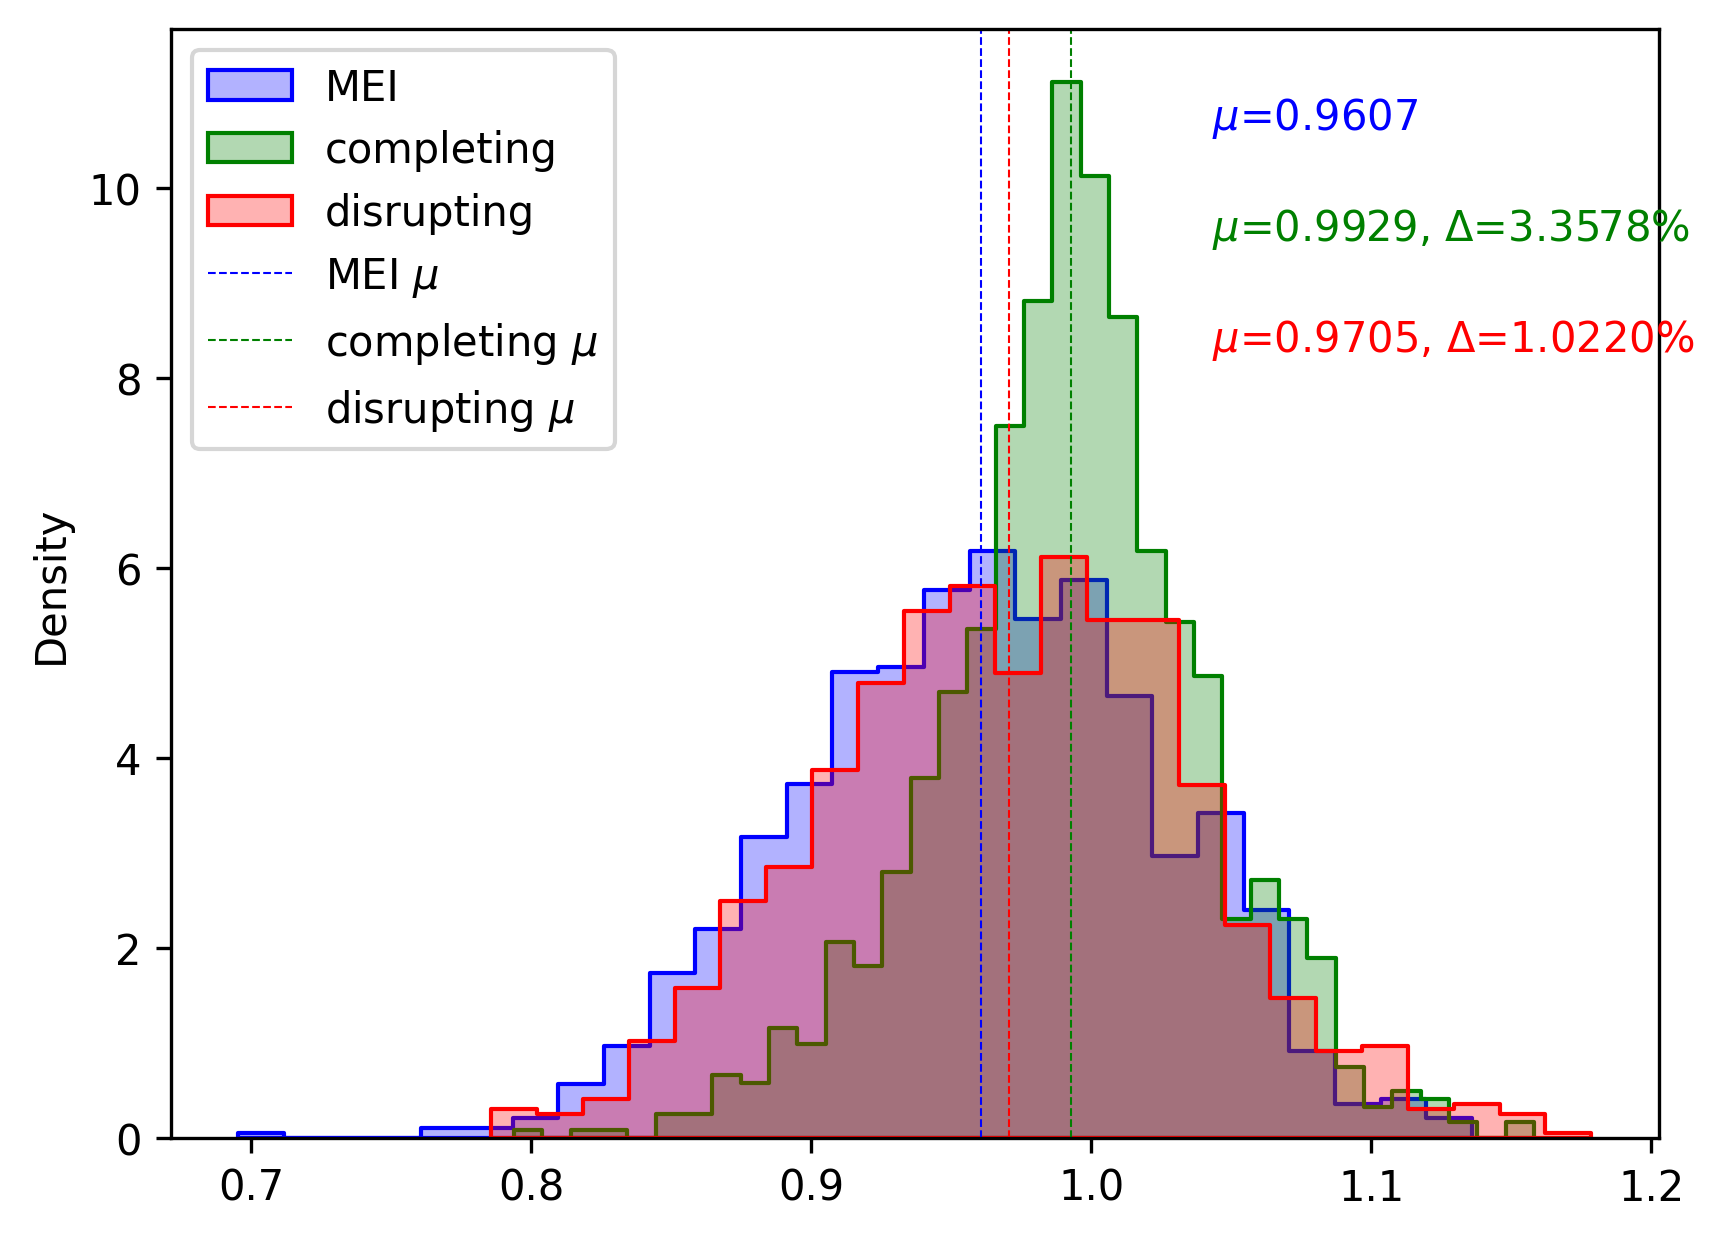

In [23]:
fig, ax = plt.subplots(dpi=300)
neuron_id = 9
sns.histplot(
    all_x_samples_reshaped[0][:, neuron_id],
    ax=ax,
    stat="density",
    color="blue",
    element="step",
    alpha=0.3,
    label="MEI"
)
sns.histplot(
    all_x_samples_reshaped[1][:, neuron_id],
    ax=ax,
    stat="density",
    color="green",
    element="step",
    alpha=0.3,
    label="completing"
)
sns.histplot(
    all_x_samples_reshaped[2][:, neuron_id],
    ax=ax,
    stat="density",
    color="red",
    element="step",
    alpha=0.3,
    label="disrupting"
)

MEI_mean = np.mean(all_x_samples_reshaped[0][:, neuron_id])
completing_mean = np.mean(all_x_samples_reshaped[1][:, neuron_id])
disrupting_mean = np.mean(all_x_samples_reshaped[2][:, neuron_id])
completing_perc_change = (completing_mean - MEI_mean) / MEI_mean
disrupting_perc_change = (disrupting_mean - MEI_mean) / MEI_mean

ax.text(0.7, 0.9, f"$\mu$={MEI_mean:.4f}", size=10, ha="left", va="bottom", transform=ax.transAxes, color='blue')
ax.text(0.7, 0.8, f"$\mu$={completing_mean:.4f}, $\Delta$={completing_perc_change*100:.4f}%", size=10, ha="left", va="bottom", transform=ax.transAxes, color='green')
ax.text(0.7, 0.7, f"$\mu$={disrupting_mean:.4f}, $\Delta$={disrupting_perc_change*100:.4f}%", size=10, ha="left", va="bottom", transform=ax.transAxes, color='red')

ax.axvline(MEI_mean, color="blue", linestyle="--", linewidth=0.5, label="MEI $\mu$")
ax.axvline(completing_mean, color="green", linestyle="--", linewidth=0.5, label="completing $\mu$")
ax.axvline(disrupting_mean, color="red", linestyle="--", linewidth=0.5, label="disrupting $\mu$")

ax.legend(loc="upper left")

In [24]:
all_samples[0]['posterior']['G'].data.mean(axis=1) 

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [25]:
# completing
all_samples[1]['posterior']['G'].data.mean(axis=1)

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [26]:
all_samples[2]['posterior']['G'].data.mean(axis=1)

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [27]:
model.gratings.shape

(2, 36, 36)

In [28]:
model.gratings.reshape(3, -1).shape

(3, 864)

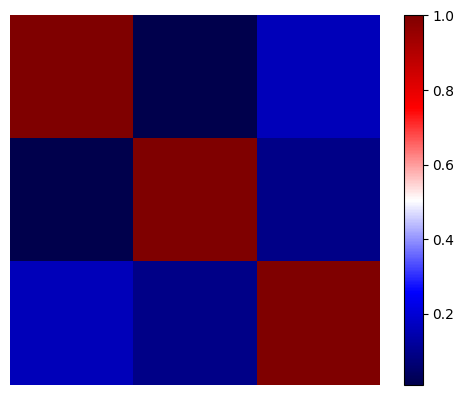

In [29]:
plt.imshow(cosine_similarity(model.gratings.reshape(3, -1)), cmap="seismic")
plt.axis('off')
plt.colorbar()